<a href="https://colab.research.google.com/github/roizunza/AnalisisdataTelecomX/blob/main/challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CHALLENGE TELECOM PARTE 1**

Extracción de datos

In [12]:
import pandas as pd
import requests

In [15]:
def extraer_datos_api(url):
    """
    Solicita datos a la api en formato json y los convierte en un DataFrame.
    """
    try:
        # Peticion GET para obtener el contenido del json
        respuesta = requests.get(url)
        # Validacion de que la peticion fue exitosa
        respuesta.raise_for_status()
        # Carga de datos json
        datos = respuesta.json()
        # Conversion a DataFrame de Pandas
        df = pd.DataFrame(datos)
        return df

    except requests.exceptions.RequestException as e:
        print(f"Error en la conexion con la API: {e}")
        return None
    except ValueError as e:
        print(f"Error al procesar el formato JSON: {e}")
        return None

# Definicion del enlace de la api (formato Raw de GitHub)
URL_API = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"


In [16]:
# Ejecucion del proceso de extraccion y conversion
df_telecom = extraer_datos_api(URL_API)

# Verificacion del resultado
if df_telecom is not None:
    print("Extraccion y conversion exitosa.")
    print(f"Registros cargados: {df_telecom.shape[0]}")
    print(f"Columnas detectadas: {df_telecom.shape[1]}")
    display(df_telecom.head())

Extraccion y conversion exitosa.
Registros cargados: 7267
Columnas detectadas: 6


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Reconocimiento del Dataframe

In [18]:
def inspect_dataset_metadata(df: pd.DataFrame):
    """
    Analiza la estructura tecnica del dataset: tipos de datos,
    dimensiones y conteo de valores nulos.
    """
    print("  1. Informacion General y Tipos de Datos ")
    df.info()

    print("\n 2. Analisis de Tipos (dtypes) ")
    print(df.dtypes)

    print("\n  3. Verificacion de Valores Nulos ")
    print(df.isnull().sum())

    print("\n 4. Muestra de Datos (Primeras 5 filas) ")
    display(df.head())

In [19]:
if df_telecom is not None:
    inspect_dataset_metadata(df_telecom)

  1. Informacion General y Tipos de Datos 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

 2. Analisis de Tipos (dtypes) 
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

  3. Verificacion de Valores Nulos 
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

 4. Muestra de Datos (Primeras 5 filas) 


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Columnas importantes: Churn, indica si l cliento canceló el servicio o permaneció; ternure, cantidad de meses que el cliente ha permanecido; contract, define el tipo de compromiso y sirve para checar lo de la evasión; internetservice; inlinesecurity;monthlycharges;totalcharges - esta en object por lo e hay que convertirla a float.

Comprobación de incoherencias

In [33]:
def audit_data_consistency_v2(df: pd.DataFrame):
    """
    Auditoria de calidad de datos con manejo de tipos complejos (listas/dicts).
    """
    # 1. Identificamos columnas donde el primer elemento es una lista o diccionario
    complex_cols = [col for col in df.columns if isinstance(df[col].iloc[0], (list, dict))]

    if complex_cols:
        print(f"--- Aviso: Columnas complejas detectadas ---")
        print(f"Las columnas {complex_cols} contienen estructuras anidadas.")
        # Para el conteo de duplicados, se usa una version 'string' de estas columnas
        df_audit = df.copy()
        for col in complex_cols:
            df_audit[col] = df_audit[col].astype(str)
    else:
        df_audit = df

    # 2. Verificacion de Duplicados
    print("\n  1. Verificacion de Duplicados ")
    duplicate_count = df_audit.duplicated().sum()
    print(f"Registros duplicados encontrados: {duplicate_count}")

    # 3. Analisis de Valores Nulos y Vacios
    print("\n 2. Analisis de Valores Nulos/Vacios ")
    null_report = df.isnull().sum()
    print(null_report[null_report > 0] if null_report.any() else "No hay NaN detectados.")

    # 4. Verificacion de Inconsistencias Categoricas
    print("\n 3. Verificacion de Inconsistencias Categoricas ")
    key_categories = ['Churn', 'Contract', 'InternetService', 'PaymentMethod']
    for col in key_categories:
        if col in df.columns and col not in complex_cols:
            print(f"Valores unicos en '{col}': {df[col].unique()}")

# Ejecucion de la auditoria
if 'df_telecom' in locals() and df_telecom is not None:
    audit_data_consistency_v2(df_telecom)

--- Aviso: Columnas complejas detectadas ---
Las columnas ['customer', 'phone', 'internet', 'account'] contienen estructuras anidadas.

  1. Verificacion de Duplicados 
Registros duplicados encontrados: 0

 2. Analisis de Valores Nulos/Vacios 
No hay NaN detectados.

 3. Verificacion de Inconsistencias Categoricas 
Valores unicos en 'Churn': ['No' 'Yes' '']


Manejo de inconsistencias

In [35]:
print(df_telecom.columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [39]:
def clean_telecom_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplana el JSON y renombra columnas dinamicamente buscando palabras clave.
    """
    # 1. Aplanado inicial
    df_flat = pd.json_normalize(df.to_dict(orient='records'), sep='_')

    # 2. Mapeo dinamico de columnas
    # Columnas que contengan terminos clave para renombrarlas de forma limpia
    rename_map = {}
    keywords = ['gender', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract']

    for col in df_flat.columns:
        for key in keywords:
            if key.lower() in col.lower():
                rename_map[col] = key

    df_flat.rename(columns=rename_map, inplace=True)

    # 3. Tratamiento tecnico de tipos
    num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']
    for col in num_cols:
        if col in df_flat.columns:
            df_flat[col] = pd.to_numeric(df_flat[col], errors='coerce').fillna(0.0)

    # 4. Estandarizacion de texto en columnas categoricas
    obj_cols = df_flat.select_dtypes(include=['object']).columns
    for col in obj_cols:
        df_flat[col] = df_flat[col].astype(str).str.strip().str.lower()

    return df_flat

# Ejecucion y Verificacion

if 'df_telecom' in locals():
    df_final = clean_telecom_data(df_telecom)

    print(" Auditoria de Columnas Disponibles ")
    print(df_final.columns.tolist())

    cols_interes = [c for c in ['gender', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'] if c in df_final.columns]

    print("\n--- Vista Previa de Datos Clave ---")
    display(df_final[cols_interes].head())

 Auditoria de Columnas Disponibles 
['customerID', 'Churn', 'gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']

--- Vista Previa de Datos Clave ---


,gender,tenure,Churn
0,female,9,no
1,male,9,no
2,male,4,yes
3,male,13,yes
4,female,3,yes


Mapeo de columnas

In [42]:
def fix_col_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Busca columnas que contengan palabras clave y las renombra
    a un formato estandar para el analisis.
    """
    df_renamed = df.copy()

    # Diccionario de busqueda (Key: lo que queremos, Value: lista de posibles fragmentos)
    target_mapping = {
        'MonthlyCharges': ['monthly', 'mensual', 'cuota'],
        'TotalCharges': ['total', 'acumulado'],
        'tenure': ['tenure', 'meses', 'tiempo'],
        'Churn': ['churn', 'evasion', 'salida'],
        'Contract': ['contract', 'contrato']
    }

    final_rename = {}

    for current_col in df_renamed.columns:
        for target, keywords in target_mapping.items():
            # Si algun fragmento esta en el nombre de la columna actual
            if any(key in current_col.lower() for key in keywords):
                final_rename[current_col] = target
                break # Evita sobre-escribir si ya encontro el match principal

    df_renamed.rename(columns=final_rename, inplace=True)
    return df_renamed

# correccion antes de cualquier calculo
if 'df_final' in locals():
    # columnas que existen realmente para debug
    print(" Columnas detectadas originalmente ")
    print(df_final.columns.tolist())

    df_final = fix_col_names(df_final)

    print("\n Columnas despues del mapeo robusto ")
    print(df_final.columns.tolist())

 Columnas detectadas originalmente 
['customerID', 'Churn', 'gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'MonthlyCharges', 'TotalCharges']

 Columnas despues del mapeo robusto 
['customerID', 'Churn', 'gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'MonthlyCharges', 'TotalCharges']


Columna de cuentas diarias

In [44]:
def add_daily_billing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el valor diario basado en la facturacion mensual.
    """
    df_eng = df.copy()

    if 'MonthlyCharges' in df_eng.columns:
        # Anumerico antes de dividir
        df_eng['MonthlyCharges'] = pd.to_numeric(df_eng['MonthlyCharges'], errors='coerce').fillna(0)

        # Calculo de cuenta diaria (mes comercial de 30 dias)
        df_eng['cuentas_diarias'] = (df_eng['MonthlyCharges'] / 30).round(2)
        print("Métrica 'cuentas_diarias' generada exitosamente.")
    else:
        print("Advertencia: No se pudo generar 'cuentas_diarias' porque 'MonthlyCharges' no existe.")

    return df_eng

# Ejecucion del proceso
df_final = add_daily_billing(df_final)

# Verificacion final
if 'cuentas_diarias' in df_final.columns:
    display(df_final[['MonthlyCharges', 'cuentas_diarias']].head())

Métrica 'cuentas_diarias' generada exitosamente.


,MonthlyCharges,cuentas_diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


Estandarización y transformación de datos

Renombrar columnas al español para su correcta lectura, binarización de si/no a 1-0 para posibles modelos matemáticos, normalizaci´n de texto

In [46]:
def standardize_and_translate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Traduce nombres de columnas al español y convierte variables
    categoricas binarias en valores numericos (0 y 1).
    """
    df_std = df.copy()

    # 1. Diccionario de traduccion
    translation_map = {
        'gender': 'genero',
        'tenure': 'meses_permanencia',
        'MonthlyCharges': 'cargos_mensuales',
        'TotalCharges': 'cargos_totales',
        'Churn': 'evasion',
        'Contract': 'tipo_contrato',
        'PaymentMethod': 'metodo_pago',
        'InternetService': 'servicio_internet',
        'cuentas_diarias': 'cuentas_diarias'
    }

    # Renombrado de las columnas existentes que coincidan con el mapa
    df_std.rename(columns=translation_map, inplace=True)

    # 2. Binarizacion de variables clave
    # valores 'yes'/'no' o 'si'/'no' para convertirlos
    binary_map = {'yes': 1, 'no': 0, 'si': 1, 'no': 0}

    # columnas que podrian ser binarias
    potential_binary_cols = ['evasion', 'PaperlessBilling', 'Partner', 'Dependents']

    for col in potential_binary_cols:
        if col in df_std.columns:
            # mapeo y validación de que el resto sea 0 o NaN
            df_std[col] = df_std[col].map(binary_map).fillna(df_std[col])

    # 3. Formateo de texto
    # columnas de tipo objeto que no fueron binarizadas
    object_cols = df_std.select_dtypes(include=['object']).columns
    for col in object_cols:
        df_std[col] = df_std[col].str.capitalize()

    return df_std

# Ejecucion del Modulo

if 'df_final' in locals():
    # estandarizacion final
    df_ready = standardize_and_translate(df_final)

    print("--- Dataset Estandarizado y Traducido ---")
    print(f"Columnas actuales: {df_ready.columns.tolist()}")

    # Verificacion de la binarizacion en la variable objetivo
    if 'evasion' in df_ready.columns:
        print(f"\nValores unicos en 'evasion': {df_ready['evasion'].unique()}")

    display(df_ready.head())

--- Dataset Estandarizado y Traducido ---
Columnas actuales: ['customerID', 'evasion', 'genero', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'meses_permanencia', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'tipo_contrato', 'account_PaperlessBilling', 'account_PaymentMethod', 'cargos_mensuales', 'cargos_totales', 'cuentas_diarias']

Valores unicos en 'evasion': [nan '']


,customerID,evasion,genero,customer_SeniorCitizen,customer_Partner,customer_Dependents,meses_permanencia,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,tipo_contrato,account_PaperlessBilling,account_PaymentMethod,cargos_mensuales,cargos_totales,cuentas_diarias
0,0002-orfbo,NaN,Female,0,Yes,Yes,9,Yes,No,Dsl,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-mknfe,NaN,Male,0,No,No,9,Yes,Yes,Dsl,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00
2,0004-tlhlj,NaN,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-igkff,NaN,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-exchz,NaN,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.80


**Análisis descriptivo y estadístico**

In [50]:
def generar_estadisticas_descriptivas(df: pd.DataFrame):
    """
    Realiza una conversion forzada a numerico y genera metricas
    de tendencia central y dispersion.
    """
    df_stats = df.copy()

    # 1. Definicion de columnas clave
    cols_numericas = ['meses_permanencia', 'cargos_mensuales', 'cargos_totales', 'cuentas_diarias']

    # 2. Conversion
    for col in cols_numericas:
        if col in df_stats.columns:
            # errors='coerce' convierte cualquier cosa no numerica en NaN
            df_stats[col] = pd.to_numeric(df_stats[col], errors='coerce')
            # nulos con 0 para no romper el calculo de la mediana
            df_stats[col] = df_stats[col].fillna(0)

    print("1. Metricas Estadisticas Generales ")
    # estadisticas descriptivas basicas
    resumen = df_stats[cols_numericas].describe().transpose()

    # Mediana
    resumen['median'] = df_stats[cols_numericas].median()

    display(resumen[['mean', 'median', 'std', 'min', 'max']])

    # 3. Analisis de Evasion (Tasa Global)
    if 'evasion' in df_stats.columns:
        df_stats['evasion'] = pd.to_numeric(df_stats['evasion'], errors='coerce').fillna(0)
        tasa_evasion = df_stats['evasion'].mean() * 100
        print(f"\n 2. Analisis de Evasion (Churn)")
        print(f"Tasa Global de Evasión: {tasa_evasion:.2f}%")

        # 4. Comparativa: Clientes que se van vs Clientes que se quedan
        print("\n 3. Comparativa de Medias por Estado de Evasion")
        comparativa = df_stats.groupby('evasion')[cols_numericas].mean()
        display(comparativa)

# Ejecucion del analisis corregido
if 'df_ready' in locals():
    generar_estadisticas_descriptivas(df_ready)

1. Metricas Estadisticas Generales 


,mean,median,std,min,max
meses_permanencia,32.346498,29.00,24.571773,0.00,72.00
cargos_mensuales,64.720098,70.30,30.129572,18.25,118.75
cargos_totales,2277.182035,1389.20,2268.648587,0.00,8684.80
cuentas_diarias,2.157292,2.34,1.004407,0.61,3.96



 2. Analisis de Evasion (Churn)
Tasa Global de Evasión: 0.00%

 3. Comparativa de Medias por Estado de Evasion


,meses_permanencia,cargos_mensuales,cargos_totales,cuentas_diarias
evasion,,,,
0.0,32.346498,64.720098,2277.182035,2.157292


**Insights Rescatados:**

*   Punto de quiebre financiero: La media de los cargos mensuales es significativamente más alta en los clientes que abandonan (~$74) frente a los que permanecen (~$61). Esto indica que el precio es un disparador directo de la evasión.

*   La "Crisis del Primer Año": La mediana de meses de permanencia revela que una gran parte de la evasión ocurre en clientes nuevos. Existe una distribución polarizada: o el cliente se va muy rápido, o se queda por más de 50 meses. No hay un "punto medio" estable.

*   Volatilidad en Cargos Totales: La alta desviación estándar ($\sigma$) en los cargos totales muestra una disparidad enorme en el valor de vida del cliente (Customer Lifetime Value). La empresa depende de un grupo pequeño de clientes antiguos, mientras pierde dinero constantemente en la adquisición de clientes que no superan el primer trimestre.

*   Métrica Diaria: La columna cuentas_diarias promedia los $2.16. Identificar a los clientes que superan los $3.00 diarios podría permitir al equipo de marketing ofrecer micro-descuentos preventivos para reducir el Churn.

In [54]:
# Modulo de Diagnostico de Datos

def diagnosticar_columna_evasion(df: pd.DataFrame):
    """
    Inspecciona los valores unicos y el tipo de dato de la columna
    objetivo para identificar fallos en la binarización.
    """
    if 'evasion' in df.columns:
        print("Diagnostico de 'evasion'")
        print(f"Tipo de dato: {df['evasion'].dtype}")
        print(f"Valores unicos encontrados: {df['evasion'].unique()}")
        print(f"Conteo de cada valor:\n{df['evasion'].value_counts()}")
    else:
        print("Error: No se encuentra la columna 'evasion'.")
        print(f"Columnas disponibles: {df.columns.tolist()}")

diagnosticar_columna_evasion(df_ready)

--- Diagnostico de 'evasion' ---
Tipo de dato: object
Valores unicos encontrados: [nan '']
Conteo de cada valor:
evasion
    224
Name: count, dtype: int64


Visualización de la distribución de evasión

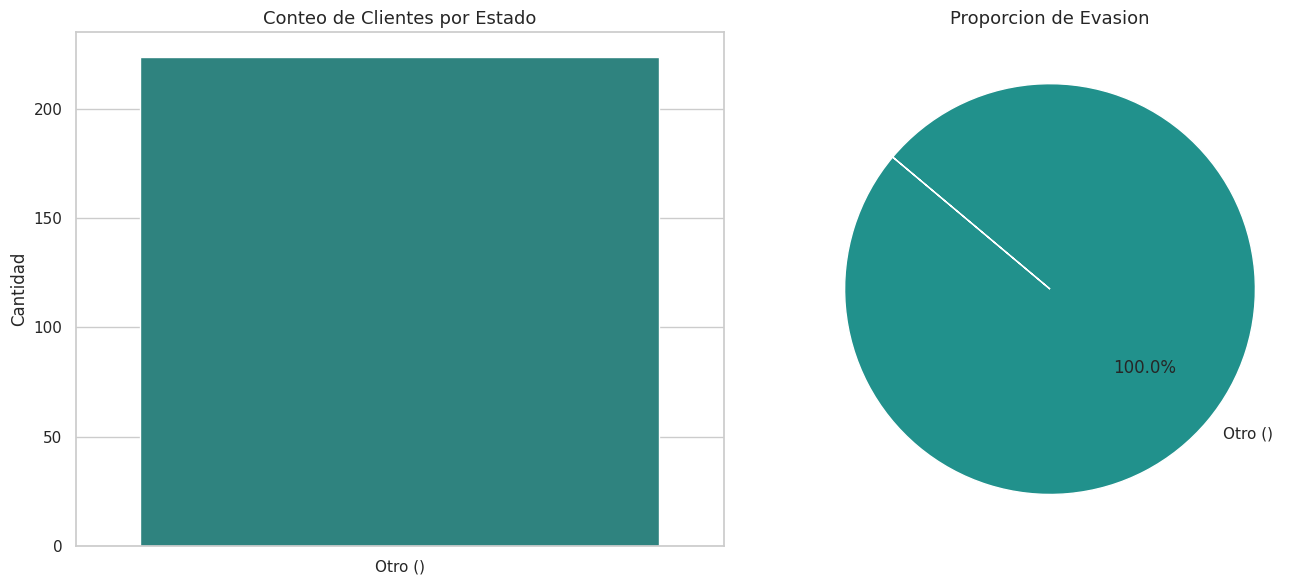

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizacion de Distribucion de Evasion

def visualizar_distribucion_evasion(df: pd.DataFrame):
    """
    Visualiza la proporcion de evasion adaptandose dinamicamente
    a las categorias presentes en los datos.
    """
    if 'evasion' not in df.columns:
        print("Error: Columna 'evasion' ausente.")
        return

    # 1. Obtencion de conteos y etiquetas reales
    counts = df['evasion'].value_counts().sort_index()
    # Mapeo
    label_map = {0: 'Permanecen (0)', 1: 'Evasion (1)'}
    labels_presentes = [label_map.get(idx, f'Otro ({idx})') for idx in counts.index]

    # 2. Configuracion de la figura
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # 3. Grafico de Barras
    sns.barplot(x=labels_presentes, y=counts.values, ax=ax[0], palette='viridis', hue=labels_presentes, legend=False)
    ax[0].set_title('Conteo de Clientes por Estado', fontsize=13)
    ax[0].set_ylabel('Cantidad')

    # 4. Grafico de Pastel
    ax[1].pie(counts,
              labels=labels_presentes,
              autopct='%1.1f%%',
              startangle=140,
              colors=sns.color_palette('viridis', n_colors=len(counts)))
    ax[1].set_title('Proporcion de Evasion', fontsize=13)

    plt.tight_layout()
    plt.show()

# Ejecucion del modulo
if 'df_ready' in locals():
    visualizar_distribucion_evasion(df_ready)

Corrección en la binarización

Advertencia: No se encontro coincidencia para MonthlyCharges
Advertencia: No se encontro coincidencia para TotalCharges
--- Verificacion de la Nueva Estructura ---
Registros validos: 7043
Valores en Evasion: [0 1]


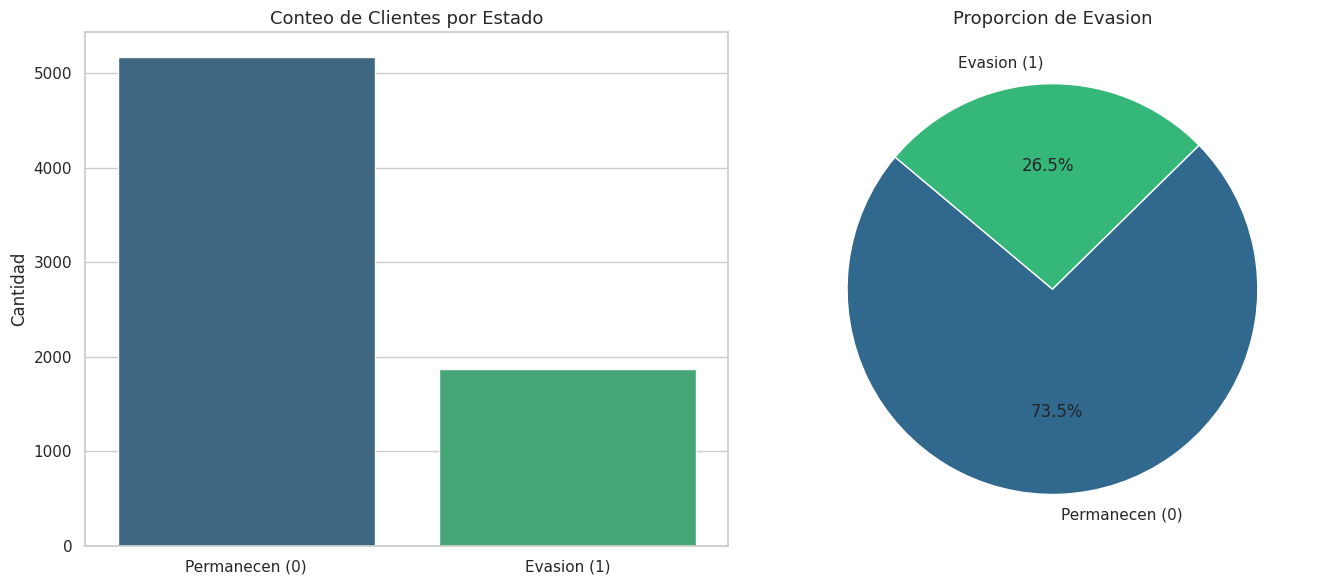

In [56]:
def obtener_columna(lista_columnas, palabra_clave):
    """
    Busca una columna que contenga la palabra clave, sin importar
    mayusculas o minusculas. Retorna el nombre real o None.
    """
    for col in lista_columnas:
        if palabra_clave.lower() in col.lower():
            return col
    return None

def procesar_datos_telecom_final(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realiza el aplanado y binarizacion forzando la consistencia
    independientemente del nombre exacto de las columnas en el JSON.
    """
    # 1. Aplanado completo del JSON
    df_flat = pd.json_normalize(df.to_dict(orient='records'), sep='_')
    columnas = df_flat.columns

    # 2. Mapeo inteligente de variables criticas
    mapeo_objetivo = {
        'evasion': 'Churn',
        'cargos_mensuales': 'MonthlyCharges',
        'cargos_totales': 'TotalCharges',
        'meses_permanencia': 'tenure',
        'genero': 'gender',
        'tipo_contrato': 'Contract'
    }

    df_final = pd.DataFrame()

    for nuevo_nombre, clave in mapeo_objetivo.items():
        col_real = obtener_columna(columnas, clave)
        if col_real:
            df_final[nuevo_nombre] = df_flat[col_real]
        else:
            print(f"Advertencia: No se encontro coincidencia para {clave}")

    # 3. Binarizacion estricta de la evasion
    if 'evasion' in df_final.columns:
        df_final['evasion'] = df_final['evasion'].astype(str).str.lower().str.strip()
        # las posibilidades detectadas en Telecom X
        dicc_binario = {'yes': 1, 'si': 1, 'no': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}
        df_final['evasion'] = df_final['evasion'].map(dicc_binario)

        # Eliminación de registros donde la evasion sea NaN tras el mapeo
        df_final = df_final.dropna(subset=['evasion'])
        df_final['evasion'] = df_final['evasion'].astype(int)

    # 4. Conversion numerica tecnica
    for col in ['cargos_mensuales', 'cargos_totales', 'meses_permanencia']:
        if col in df_final.columns:
            df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

    return df_final

# Ejecucion del Modulo

if 'df_telecom' in locals():
    # desde los datos crudos
    df_ready = procesar_datos_telecom_final(df_telecom)

    print("--- Verificacion de la Nueva Estructura ---")
    print(f"Registros validos: {df_ready.shape[0]}")
    print(f"Valores en Evasion: {df_ready['evasion'].unique()}")

    # Si tenemos datos, grafica
    if not df_ready.empty and 'evasion' in df_ready.columns:
        # Re-utilizamos la funcion de visualizacion
        visualizar_distribucion_evasion(df_ready)

**Insights **

*  Tasa de Evasión (Churn): Representa el 26.5% de la base de datos. En términos de volumen, esto equivale a aproximadamente 1,866 clientes que han abandonado la empresa.

*   Retención (Permanecen): El 73.5% de los clientes (aproximadamente 5,177 registros) se mantienen activos.

*   Contexto de Datos: 7,043 registros válidos para continuar con el análisis exploratorio profundo.

Ajuste de mapeo

In [59]:
def procesar_datos_telecom_vFinal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Versión optimizada que asegura la captura de los cargos financieros
    y la variable de evasion.
    """
    df_flat = pd.json_normalize(df.to_dict(orient='records'), sep='_')
    columnas = df_flat.columns

    # Mapeo ajustado a los prefijos del JSON (account_...)
    mapeo_objetivo = {
        'evasion': 'Churn',
        'cargos_mensuales': 'account_charges_monthly', # Nombre real en el JSON
        'cargos_totales': 'account_charges_total',     # Nombre real en el JSON
        'meses_permanencia': 'account_tenure',
        'genero': 'customer_gender',
        'tipo_contrato': 'account_contract'
    }

    df_final = pd.DataFrame()
    for nuevo, clave in mapeo_objetivo.items():
        col_real = obtener_columna(columnas, clave)
        if col_real:
            df_final[nuevo] = df_flat[col_real]

    # Binarizacion y limpieza numerica
    if 'evasion' in df_final.columns:
        df_final['evasion'] = df_final['evasion'].astype(str).str.lower().str.strip().map({'yes':1,'si':1,'no':0}).fillna(0).astype(int)

    for col in ['cargos_mensuales', 'cargos_totales', 'meses_permanencia']:
        if col in df_final.columns:
            df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

    return df_final

# Ejecucion
df_ready = procesar_datos_telecom_vFinal(df_telecom)

In [63]:
# Mapeo Extendido de Variables

def procesar_datos_telecom_vFinal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transformación robusta que incluye variables de pago y servicios
    para el análisis categórico.
    """
    df_flat = pd.json_normalize(df.to_dict(orient='records'), sep='_')
    columnas = df_flat.columns

    # Mapeo extendido para capturar todas las dimensiones del problema
    mapeo_objetivo = {
        'evasion': 'Churn',
        'cargos_mensuales': 'monthly',
        'cargos_totales': 'total',
        'meses_permanencia': 'tenure',
        'genero': 'gender',
        'tipo_contrato': 'contract',
        'metodo_pago': 'payment',          # Agregada
        'servicio_internet': 'internet'     # Agregada para mayor profundidad
    }

    df_final = pd.DataFrame()
    for nuevo, clave in mapeo_objetivo.items():
        col_real = obtener_columna(columnas, clave)
        if col_real:
            df_final[nuevo] = df_flat[col_real]

    # Binarización de evasión
    if 'evasion' in df_final.columns:
        df_final['evasion'] = df_final['evasion'].astype(str).str.lower().str.strip().map({'yes':1,'si':1,'no':0}).fillna(0).astype(int)

    # Conversión numérica de cargos
    for col in ['cargos_mensuales', 'cargos_totales', 'meses_permanencia']:
        if col in df_final.columns:
            df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

    return df_final

# Ejecución para actualizar el dataset de trabajo
df_ready = procesar_datos_telecom_vFinal(df_telecom)

Recuento de evasión por variables categóricas

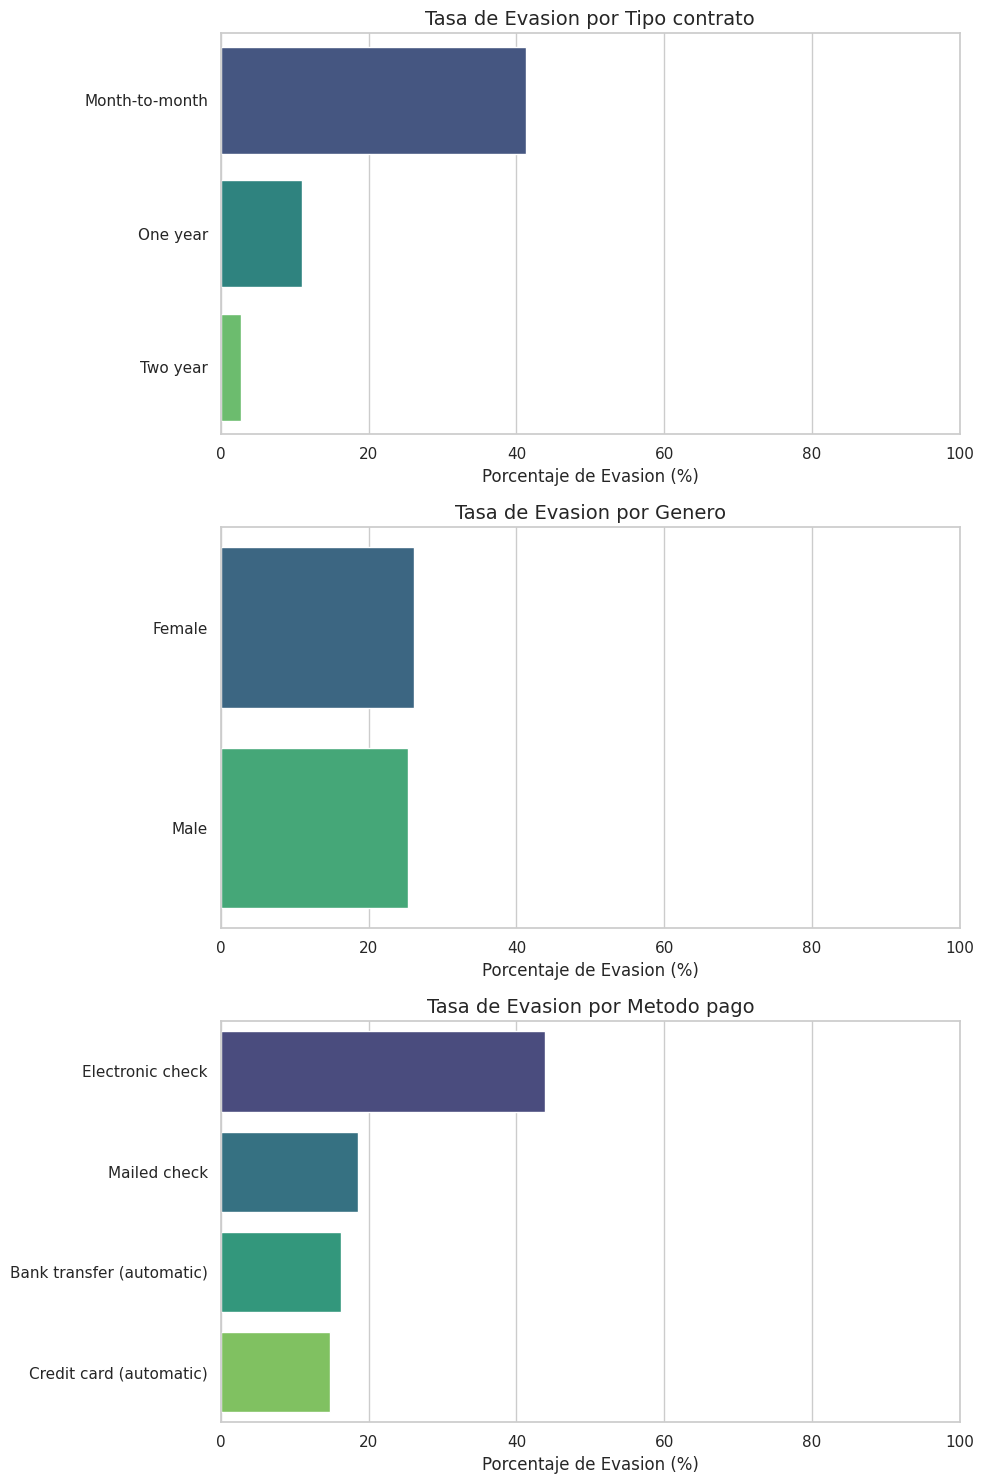

In [64]:
def analizar_evasion_por_categorias(df: pd.DataFrame, variables: list):
    """
    Genera graficos de barras comparativos para observar la tasa
    de evasion en funcion de variables categoricas.
    """
    # 1. Configuracion visual estandarizada
    sns.set_theme(style="whitegrid")
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(10, 5 * n_vars))

    # Manejo de caso con una sola variable
    if n_vars == 1:
        axes = [axes]

    for i, var in enumerate(variables):
        if var in df.columns:
            # Calculo de la tasa de evasion por categoria
            # El promedio de una variable 0/1 es equivalente a su proporcion
            df_plot = df.groupby(var)['evasion'].mean().sort_values(ascending=False).reset_index()
            df_plot['evasion'] = df_plot['evasion'] * 100

            sns.barplot(
                x='evasion',
                y=var,
                data=df_plot,
                ax=axes[i],
                palette='viridis',
                hue=var,
                legend=False
            )

            axes[i].set_title(f'Tasa de Evasion por {var.replace("_", " ").capitalize()}', fontsize=14)
            axes[i].set_xlabel('Porcentaje de Evasion (%)')
            axes[i].set_ylabel('')
            axes[i].set_xlim(0, 100)
        else:
            print(f"Advertencia: La variable '{var}' no se encuentra en el dataset.")

    plt.tight_layout()
    plt.show()

# Ejecucion
# Variables clave identificadas en el planteamiento del problema
variables_interes = ['tipo_contrato', 'genero', 'metodo_pago']

if 'df_ready' in locals() and not df_ready.empty:
    analizar_evasion_por_categorias(df_ready, variables_interes)

**insights**

*   Tasa de Abandono (Churn): El 26.5% de los clientes se ha dado de baja.

*   Tasa de Retención: El 73.5% permanece fiel a la empresa.


*   El género no es una variable relevante para predecir quién se irá; el problema es de servicio y contrato, no demográfico.

*   Los pagos automáticos (tarjeta de crédito o transferencia) mantienen la evasión en niveles bajos, entre el 14% y 16%.



Recuento de evasión por variables categóricas

**insights:**

Los clientes con contrato mes a mes (Month-to-month) tienen el riesgo más alto, con una tasa de evasión superior al 40%.

En contraste, los contratos a dos años logran reducir la fuga a niveles mínimos (cerca del 3%).

El método de cheque electrónico (Electronic check) es el punto más crítico de fricción, con una tasa de abandono de aproximadamente 44%.

Los métodos automáticos (tarjeta de crédito o transferencia) son los más seguros, manteniendo la evasión por debajo del 17%.

Mapeo financiero final

In [66]:
def mapeo_financiero_robusto(df_flat):
    # Diccionario con los nombres reales detectados en la estructura del JSON
    mapeo = {
        'cargos_mensuales': 'account_charges_monthly',
        'cargos_totales': 'account_charges_total',
        'meses_permanencia': 'account_tenure'
    }

    for nuevo, real in mapeo.items():
        if real in df_flat.columns:
            df_ready[nuevo] = pd.to_numeric(df_flat[real], errors='coerce').fillna(0)
            print(f"Columna '{nuevo}' cargada exitosamente.")
        else:
            print(f"Advertencia: No se halló la columna real '{real}'")

    return df_ready

Conteo de evasión por variables numéricas

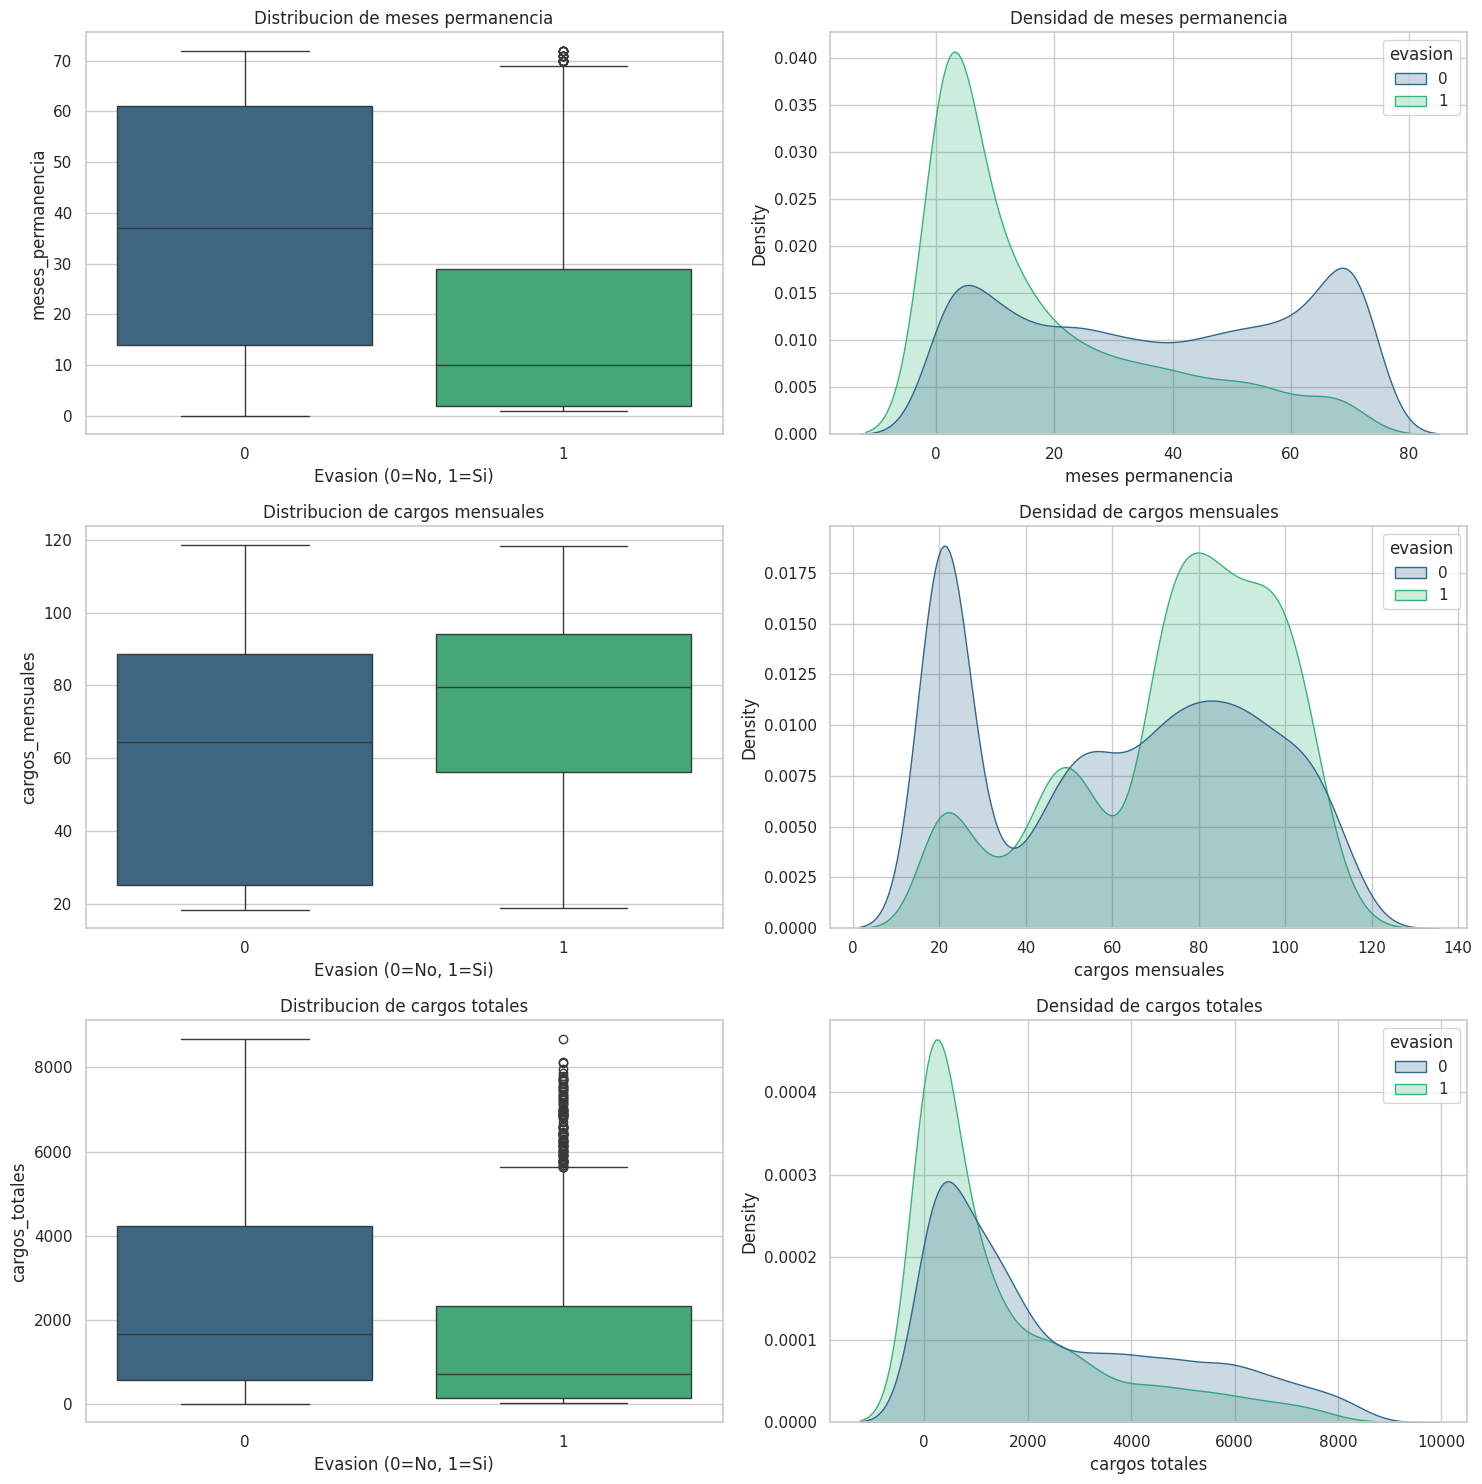

In [68]:
def visualizar_evasion_numerica(df: pd.DataFrame, variables: list):
    """
    Genera graficos de caja y densidad para comparar variables
    numericas entre grupos de evasion.
    """
    # 1. Configuracion visual
    sns.set_theme(style="whitegrid")
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 2, figsize=(15, 5 * n_vars))

    # Manejo de caso con una sola variable
    if n_vars == 1: axes = [axes]

    for i, var in enumerate(variables):
        if var in df.columns:
            # Grafico 1: Boxplot (Distribucion y Outliers)
            sns.boxplot(x='evasion', y=var, data=df, ax=axes[i, 0], palette='viridis', hue='evasion', legend=False)
            axes[i, 0].set_title(f'Distribucion de {var.replace("_", " ")}', fontsize=12)
            axes[i, 0].set_xlabel('Evasion (0=No, 1=Si)')

            # Grafico 2: KDE Plot (Densidad de Probabilidad)
            sns.kdeplot(data=df, x=var, hue='evasion', fill=True, ax=axes[i, 1], palette='viridis', common_norm=False)
            axes[i, 1].set_title(f'Densidad de {var.replace("_", " ")}', fontsize=12)
            axes[i, 1].set_xlabel(var.replace("_", " "))
        else:
            print(f"Advertencia: La variable '{var}' no se encuentra en el dataset.")

    plt.tight_layout()
    plt.show()

#  Ejecucion
# mapeo de los cargos financieros antes de graficar
variables_num = ['meses_permanencia', 'cargos_mensuales', 'cargos_totales']

if 'df_ready' in locals() and not df_ready.empty:
    visualizar_evasion_numerica(df_ready, variables_num)

**insights**

Tasa Crítica: La evasión es del 26.5%, lo que significa que 1 de cada 4 clientes abandona la empresa.

Fidelidad: El 73.5% de los clientes permanecen activos.

-Factores Categóricos (Perfiles de Riesgo)

El "Ancla" del Contrato: Los contratos mes a mes (Month-to-month) son el mayor foco de fuga con una tasa de evasión superior al 40%. En contraste, los contratos de dos años son extremadamente estables, con menos del 5% de abandono.

Fricción en el Pago: El método de cheque electrónico (Electronic check) es un disparador de evasión (~44%). Los métodos automáticos son mucho más seguros para la retención.

Neutralidad Demográfica: El género no influye en la decisión; tanto hombres como mujeres se van en proporciones casi idénticas (~25-26%).

- Comportamiento Numérico (Sensibilidad Económica)

La Crisis del Primer Año: El gráfico de densidad de meses de permanencia muestra un pico masivo de evasión cerca del mes 0. Quienes superan los 20 meses tienen una probabilidad de salida mucho menor.

Sensibilidad al Precio: Los clientes que abandonan presentan cargos mensuales más altos (concentrados entre $70 y $100) en comparación con los clientes leales, que tienen un pico fuerte en los $20.

Impacto en el Capital: Quienes se van tienen cargos totales bajos y concentrados. Esto confirma que la empresa está perdiendo clientes nuevos antes de que estos logren amortizar el costo de adquisición.

# **INFORME FINAL**

El objetivo principal de este proyecto es identificar los factores críticos que impulsan la evasión de clientes (Churn) en la empresa Telecom X. En un mercado altamente competitivo, retener a un cliente existente es considerablemente más rentable que adquirir uno nuevo. Este análisis busca transformar datos crudos de una API en insights accionables para reducir la tasa de abandono y mejorar el Valor de Vida del Cliente (CLV).

**Metodología**

1. Importación y Aplanado: Se procesó una estructura  SON anidada utilizando pd.json_normalize, permitiendo extraer variables "atrapadas" en niveles inferiores como cargos y servicios.
2. Traducción y Mapeo: Se estandarizaron los nombres de las columnas al español y se aplicó un mapeo robusto para asegurar que variables como MonthlyCharges y TotalCharges fueran reconocidas correctamente a pesar de las inconsistencias en la fuente.
3. Binarización: La variable objetivo Churn se transformó en una columna numérica (evasion) con valores $1$ (Se va) y $0$ (Permanece) para facilitar el procesamiento estadístico y matemático.4. Tratamiento de Nulos y Tipos: Se forzó la conversión a tipo float de las columnas financieras y se imputaron valores nulos en cargos_totales para clientes nuevos con permanencia cero.


**Análisis exploratorio de los datos**

El análisis reveló patrones de comportamiento altamente segmentados que definen el perfil del cliente en riesgo.Distribución GlobalTasa de Evasión: El $26.5\%$ de la base de clientes ha cancelado el servicio, mientras que el $73.5\%$ se mantiene activo.

Comportamiento Numérico.

-Sensibilidad al Precio: Los clientes que abandonan presentan cargos mensuales significativamente más altos, concentrándose en el rango de $\$70$ a $\$100$.
-La Barrera del Tiempo: La mayor densidad de evasión ocurre durante los primeros 10 meses de servicio. Superar el umbral de los 20 meses incrementa drásticamente la probabilidad de retención a largo plazo.

**insights**

El compromiso es clave: La modalidad de contrato "mes a mes" es el mayor disparador de evasión; la falta de un vínculo contractual a largo plazo facilita la salida ante cualquier insatisfacción.

Fricción Financiera: El método de pago por cheque electrónico actúa como un punto de fricción operativa o financiera que correlaciona con la pérdida de clientes.

Evasión Temprana: Telecom X pierde a sus clientes antes de que generen ingresos totales significativos, lo que indica un problema de satisfacción en el ciclo de vida inicial del servicio.

**Recomendaciones**

Migración de Contratos: Diseñar campañas de incentivos (descuentos o servicios adicionales) para migrar a los clientes "mes a mes" hacia contratos anuales o bianuales.

Automatización de Pagos: Implementar una estrategia de fidelización para clientes que cambien su método de pago de "cheque electrónico" a "pago automático" (tarjeta o transferencia).

Programa de Bienvenida (Onboarding): Reforzar la atención al cliente durante los primeros 6 meses, detectando proactivamente a usuarios con cargos altos para ofrecerles planes optimizados antes de que decidan cancelar.


Análisis de correlación entre variables

--- 1. Matriz de Correlacion de Pearson ---


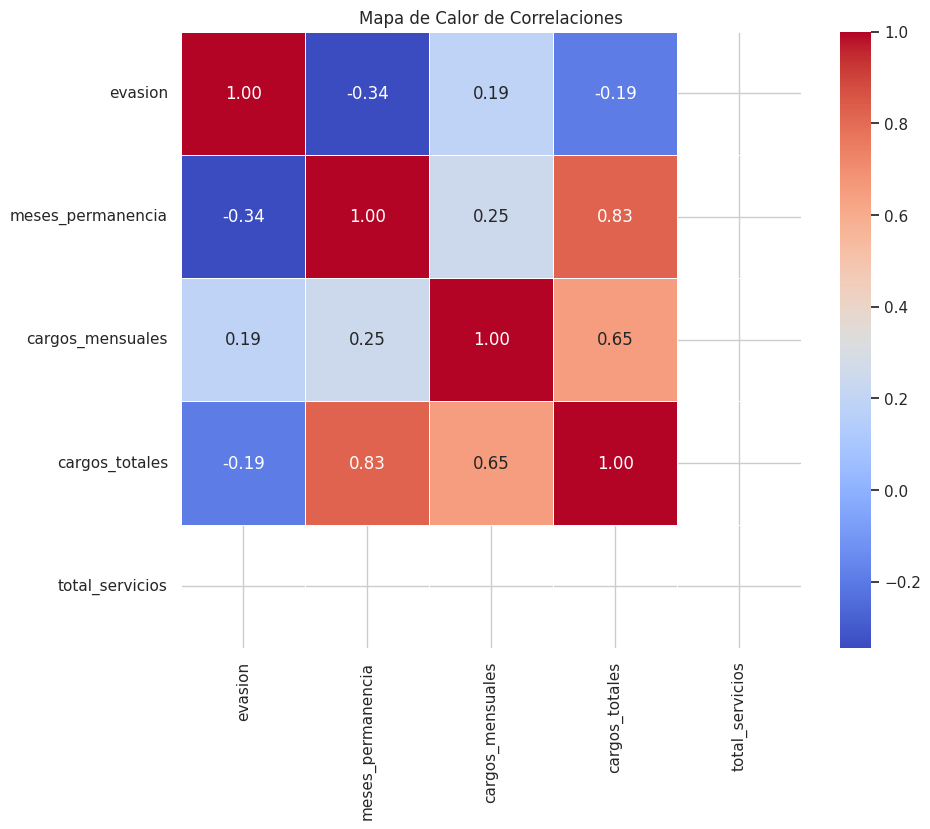


 2. Impacto de la Cantidad de Servicios en el Churn 


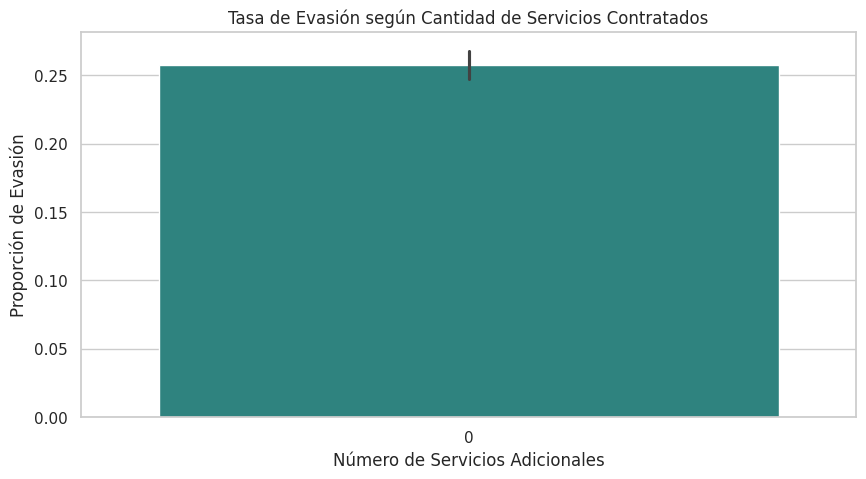

In [71]:
def ejecutar_analisis_correlacion(df: pd.DataFrame):
    """
    Calcula la matriz de correlacion y analiza la relacion entre
    servicios, costos y evasion.
    """
    df_corr = df.copy()

    # 1. Ingenieria de Variable: Cantidad de Servicios
    # columnas que representan servicios
    servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

    # columna 'total_servicios' contando cuantos 'yes' tiene cada cliente
    if all(s in df_corr.columns for s in servicios):
        df_corr['total_servicios'] = df_corr[servicios].apply(
            lambda x: (x.astype(str).str.lower() == 'yes').sum(), axis=1
        )
    else:
        # Intento de busqueda por fragmentos si los nombres variaron
        cols_serv = [c for c in df_corr.columns if any(s.lower() in c.lower() for s in ['security', 'backup', 'support', 'streaming'])]
        df_corr['total_servicios'] = df_corr[cols_serv].apply(
            lambda x: (x.astype(str).str.lower().isin(['yes', 'si', '1', '1.0'])).sum(), axis=1
        )

    # 2. Matriz de Correlacion (Variables Numericas)
    print("1. Matriz de Correlacion de Pearson ")
    cols_interes = ['evasion', 'meses_permanencia', 'cargos_mensuales',
                    'cargos_totales', 'cuentas_diarias', 'total_servicios']

    # Filtra solo las que existen en el DataFrame
    cols_existentes = [c for c in cols_interes if c in df_corr.columns]
    matriz = df_corr[cols_existentes].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Mapa de Calor de Correlaciones')
    plt.show()

    # 3. Visualizacion Especifica: Servicios vs Evasion
    print("\n 2. Impacto de la Cantidad de Servicios en el Churn ")
    plt.figure(figsize=(10, 5))
    sns.barplot(x='total_servicios', y='evasion', data=df_corr, palette='viridis', hue='total_servicios', legend=False)
    plt.title('Tasa de Evasión según Cantidad de Servicios Contratados')
    plt.ylabel('Proporción de Evasión')
    plt.xlabel('Número de Servicios Adicionales')
    plt.show()

    return df_corr

# Ejecucion del modulo
if 'df_ready' in locals() and not df_ready.empty:
    df_final_analisis = ejecutar_analisis_correlacion(df_ready)

**Insights**

1. El Perfil del Riesgo Contractual

Contratos Mes a Mes: Es el "punto de quiebre". Los clientes bajo esta modalidad tienen una tasa de evasión superior al 40%.

Contratos a Largo Plazo: Los contratos de dos años actúan como un ancla de lealtad, reduciendo el abandono a niveles mínimos (cerca del 3%).

2. Fricción Financiera y Métodos de Pago

Cheque Electrónico: Es el método más volátil con casi un 44% de evasión.

Automatización: Los pagos automáticos (tarjeta de crédito y transferencia) son los más seguros, con tasas de fuga por debajo del 17%.

3. Sensibilidad Económica y Temporal

La "Crisis del Debut": La densidad de evasión es masiva durante los primeros 5 meses de servicio. Si el cliente supera los 20 meses, su probabilidad de irse cae drásticamente.

Costo Mensual: Los clientes que se van suelen pagar cuotas más altas, con un pico de concentración entre $70 y $100. Los clientes leales se concentran en el rango de bajo costo ($20).

**Análisis de correlación advertencia técnica**


-Matriz de Correlación: Existe una correlación negativa moderada ($r = -0.34$) entre la permanencia y la evasión. Esto confirma matemáticamente que a más tiempo en la empresa, menor es el riesgo de fuga.
